In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import mlflow
import mlflow.xgboost
import warnings
warnings.filterwarnings('ignore')

master_df = pd.read_csv("../data/processed/master_features.csv")

print(f"Loaded {len(master_df)} companies")
print(f"Columns: {len(master_df.columns)}")

Loaded 503 companies
Columns: 45


In [2]:
target = 'enterprise_value'

features = [
    'revenue', 'gross_profit', 'ebitda', 'net_income', 'free_cash_flow',
    'operating_cash_flow', 'total_debt', 'total_cash', 'shares_outstanding',
    'pe_ratio', 'forward_pe', 'ps_ratio', 'pb_ratio', 'ev_revenue',
    'peg_ratio', 'beta', 'gross_margin', 'ebitda_margin', 'net_margin',
    'fcf_margin', 'roe', 'roa', 'debt_to_equity', 'current_ratio',
    'quick_ratio', 'dividend_yield', 'fifty_two_week_position', 'net_debt',
    'p_fcf', 'altman_z_score'
]

df_model = master_df[['symbol', 'name', 'sector'] + features + [target]].copy()
df_model = df_model.dropna(subset=features + [target])

print(f"Companies available for modeling: {len(df_model)}")
print(f"Features: {len(features)}")
print(f"\nTarget variable summary:")
print(df_model[target].describe())

Companies available for modeling: 428
Features: 30

Target variable summary:
count    4.280000e+02
mean     1.459965e+11
std      4.300756e+11
min      8.195955e+09
25%      2.666866e+10
50%      5.245483e+10
75%      1.110288e+11
max      5.251214e+12
Name: enterprise_value, dtype: float64


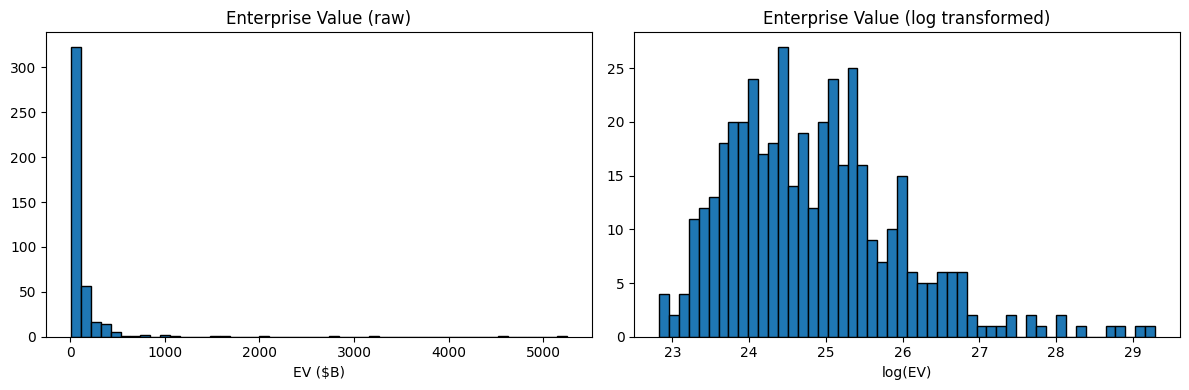

Raw EV skewness: 8.422
Log EV skewness: 0.908


In [3]:
import matplotlib.pyplot as plt

df_model['ev_log'] = np.log(df_model[target])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_model[target]/1e9, bins=50, edgecolor='black')
axes[0].set_title('Enterprise Value (raw)')
axes[0].set_xlabel('EV ($B)')

axes[1].hist(df_model['ev_log'], bins=50, edgecolor='black')
axes[1].set_title('Enterprise Value (log transformed)')
axes[1].set_xlabel('log(EV)')

plt.tight_layout()
plt.show()

print("Raw EV skewness:", round(df_model[target].skew(), 3))
print("Log EV skewness:", round(df_model['ev_log'].skew(), 3))

In [4]:
X = df_model[features]
y = df_model['ev_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} companies")
print(f"Test set: {len(X_test)} companies")

Training set: 342 companies
Test set: 86 companies


In [5]:
mlflow.set_experiment("ev_valuation_model")

with mlflow.start_run(run_name="xgboost_baseline"):
    
    params = {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'max_depth': 4,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42
    }
    
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    y_pred_log = model.predict(X_test)
    y_pred = np.exp(y_pred_log)
    y_actual = np.exp(y_test)
    
    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)
    mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
    
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mape", mape)
    mlflow.xgboost.log_model(model, "model")
    
    print(f"R² Score:  {r2:.4f}")
    print(f"MAE:       ${mae/1e9:,.1f}B")
    print(f"MAPE:      {mape:.1f}%")
    print(f"\nInterpretation:")
    print(f"  The model explains {r2*100:.1f}% of variance in enterprise value")
    print(f"  Average prediction error: {mape:.1f}%")

2026/06/05 20:44:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/05 20:44:29 INFO mlflow.store.db.utils: Updating database tables
2026/06/05 20:44:30 INFO mlflow.tracking.fluent: Experiment with name 'ev_valuation_model' does not exist. Creating a new experiment.
2026/06/05 20:44:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


R² Score:  0.9176
MAE:       $19.0B
MAPE:      14.4%

Interpretation:
  The model explains 91.8% of variance in enterprise value
  Average prediction error: 14.4%


In [7]:
results_df = pd.DataFrame({
    'symbol': df_model.loc[X_test.index, 'symbol'].values,
    'name': df_model.loc[X_test.index, 'name'].values,
    'actual_ev_b': (y_actual.values / 1e9).round(1),
    'predicted_ev_b': (y_pred / 1e9).round(1),
})

results_df['error_pct'] = ((results_df['predicted_ev_b'] - results_df['actual_ev_b']) / results_df['actual_ev_b'] * 100).round(1)

print("10 most accurate predictions:")
print(results_df.reindex(results_df['error_pct'].abs().nsmallest(10).index)[['symbol', 'name', 'actual_ev_b', 'predicted_ev_b', 'error_pct']].to_string())

print("\n10 least accurate predictions:")
print(results_df.reindex(results_df['error_pct'].abs().nlargest(10).index)[['symbol', 'name', 'actual_ev_b', 'predicted_ev_b', 'error_pct']].to_string())

10 most accurate predictions:
   symbol                                   name  actual_ev_b  predicted_ev_b  error_pct
12    HLT         Hilton Worldwide Holdings Inc.         89.5       89.500000        0.0
54    AEP  American Electric Power Company, Inc.        122.0      122.300003        0.2
73   TSCO                 Tractor Supply Company         21.6       21.500000       -0.5
78   NDSN                    Nordson Corporation         17.8       17.700001       -0.6
35     CF           CF Industries Holdings, Inc.         22.5       22.299999       -0.9
63     KO                  The Coca-Cola Company        363.4      366.700012        0.9
32    RMD                            ResMed Inc.         27.4       27.100000       -1.1
13    WSM                  Williams-Sonoma, Inc.         25.3       25.600000        1.2
8     FRT        Federal Realty Investment Trust         15.7       15.500000       -1.3
31    MAR           Marriott International, Inc.        118.6      116.900002   

In [8]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap_df = pd.DataFrame(shap_values, columns=features)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

print("Top 15 most important features:")
for i, (feature, importance) in enumerate(mean_shap.head(15).items()):
    print(f"  {i+1:2}. {feature:<30} {importance:.4f}")

Top 15 most important features:
   1. net_income                     0.2725
   2. operating_cash_flow            0.2613
   3. ebitda                         0.1132
   4. pe_ratio                       0.1073
   5. forward_pe                     0.0823
   6. ev_revenue                     0.0715
   7. total_debt                     0.0531
   8. net_debt                       0.0489
   9. ps_ratio                       0.0448
  10. gross_profit                   0.0377
  11. revenue                        0.0375
  12. total_cash                     0.0287
  13. p_fcf                          0.0271
  14. shares_outstanding             0.0258
  15. pb_ratio                       0.0256


In [10]:
print("10 most OVERVALUED by model (current price > fair value):")
over = df_model.nsmallest(10, 'upside_pct')[['symbol', 'name', 'current_price', 'fair_value_per_share', 'upside_pct']]
for _, row in over.iterrows():
    print(f"  {row['symbol']:<6} {row['name'][:35]:<35} Current: ${row['current_price']:>8,.2f}  Fair Value: ${row['fair_value_per_share']:>8,.2f}  Upside: {row['upside_pct']:>+.1f}%")

print("\n10 most UNDERVALUED by model (fair value > current price):")
under = df_model.nlargest(10, 'upside_pct')[['symbol', 'name', 'current_price', 'fair_value_per_share', 'upside_pct']]
for _, row in under.iterrows():
    print(f"  {row['symbol']:<6} {row['name'][:35]:<35} Current: ${row['current_price']:>8,.2f}  Fair Value: ${row['fair_value_per_share']:>8,.2f}  Upside: {row['upside_pct']:>+.1f}%")

10 most OVERVALUED by model (current price > fair value):
  DVN    Devon Energy Corporation            Current: $   44.80  Fair Value: $   24.66  Upside: -45.0%
  NKE    NIKE, Inc.                          Current: $   42.97  Fair Value: $   32.37  Upside: -24.7%
  J      Jacobs Solutions Inc.               Current: $  123.50  Fair Value: $   93.28  Upside: -24.5%
  AVGO   Broadcom Inc.                       Current: $  391.00  Fair Value: $  299.08  Upside: -23.5%
  WY     Weyerhaeuser Company                Current: $   24.70  Fair Value: $   18.98  Upside: -23.2%
  SOLV   Solventum Corporation               Current: $   81.10  Fair Value: $   62.90  Upside: -22.4%
  TMUS   T-Mobile US, Inc.                   Current: $  179.93  Fair Value: $  142.48  Upside: -20.8%
  GRMN   Garmin Ltd.                         Current: $  238.38  Fair Value: $  192.55  Upside: -19.2%
  IQV    IQVIA Holdings Inc.                 Current: $  183.60  Fair Value: $  149.34  Upside: -18.7%
  EIX    Edison

In [11]:
import pickle

df_model[['symbol', 'name', 'current_price', 'fair_value_per_share', 'upside_pct', 'predicted_ev']].to_csv("../data/processed/ml_valuations.csv", index=False)

shap_importance = pd.DataFrame({
    'feature': features,
    'importance': shap_df.abs().mean().values
}).sort_values('importance', ascending=False)
shap_importance.to_csv("../data/processed/shap_importance.csv", index=False)

with open("../data/processed/xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("../data/processed/model_features.pkl", "wb") as f:
    pickle.dump(features, f)

print("Saved:")
print("  ml_valuations.csv")
print("  shap_importance.csv")
print("  xgboost_model.pkl")
print("  model_features.pkl")

Saved:
  ml_valuations.csv
  shap_importance.csv
  xgboost_model.pkl
  model_features.pkl
